# SHAP-IMV — Titanic

Exact Shapley attribution with IMV as the coalition value, on the OpenML Titanic
dataset (binary: survived).

`Title` is extracted from the passenger name, so this specification includes the
eight-feature set used in the published figure. Note that `Title` is almost
perfectly nested inside `Sex`, and Shapley symmetry makes near-redundant features
share credit — expect the two to split attribution.

**Pipeline**: download from OpenML → preprocess → standardise → 10 seeds × 3
estimators × exact power set → aggregate.

Full documentation: `documentation/examples/shap_imv/titanic.md`.

In [1]:
import os, sys, tempfile, warnings, itertools
from pathlib import Path

_PATH_DISPLAY_ROOT = Path()

def relative_path(path, *, start=None):
    """Return a display-only path relative to an explicit local anchor."""
    anchor = Path(start) if start is not None else _PATH_DISPLAY_ROOT
    try:
        relative = os.path.relpath(Path(path).expanduser().resolve(),
                                   start=anchor.expanduser().resolve())
    except ValueError:  # Paths on different Windows drives cannot be relativized.
        relative = Path(path).name
    return Path(relative).as_posix()

def _relative_warning_text(message):
    text = str(message)
    roots = {Path.home(), Path(sys.prefix), Path(sys.base_prefix),
             _PATH_DISPLAY_ROOT, Path(tempfile.gettempdir())}
    for root in sorted(roots, key=lambda value: len(str(value)), reverse=True):
        absolute = str(root.expanduser().resolve())
        text = text.replace(absolute, relative_path(absolute))
    return text

def _show_relative_warning(message, category, filename, lineno, file=None, line=None):
    stream = file if file is not None else sys.stderr
    warning_text = _relative_warning_text(message)
    print(f"{relative_path(filename)}:{lineno}: {category.__name__}: {warning_text}", file=stream)

warnings.showwarning = _show_relative_warning

%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# No dataset is stored in this repository. Everything downloads on demand into a
# user-level cache outside the working tree.
CACHE = Path(os.environ.get("IMV_CACHE_HOME", Path.home() / ".cache" / "imv"))
CACHE.mkdir(parents=True, exist_ok=True)

DATA_HOME = Path(os.environ.get("IMV_DATA_CACHE", CACHE / "datasets")) / "openml"
ARTIFACTS = Path(os.environ.get("IMV_ARTIFACT_CACHE", CACHE / "notebook_artifacts")) / "shap_imv_titanic"
RESULTS = ARTIFACTS / "results"; RESULTS.mkdir(parents=True, exist_ok=True)
PROJECT_ROOT = next(
    (path for path in (Path.cwd(), *Path.cwd().parents)
     if (path / "requirements.txt").is_file() and (path / "src").is_dir()),
    Path.cwd(),
)
FIGURES = Path(os.environ.get(
    "IMV_FIGURE_DIR", PROJECT_ROOT / "output" / "figures"
))
FIGURES.mkdir(parents=True, exist_ok=True)
if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "src"))
from figure_utils import (
    COLORMAP, configure_plotting, spectral_colors,
    save_publication_figure as save_figure,
)
configure_plotting()
FORCE_RECOMPUTE = os.environ.get("IMV_FORCE_RECOMPUTE", "0").strip().lower() in {
    "1", "true", "yes",
}

# Ten seeds, as required for any reported IMV result. The seed drives the fold
# split and the estimator, so every number below is a mean over ten independent
# fold partitions.
SEEDS = [42, 43, 44, 45, 46, 47, 48, 49, 50, 51]
N_SPLITS = 5

import imvpy
from imvpy import BinaryIMV

IMVPY_SOURCE = Path(imvpy.__file__).resolve().parent
print(f"imvpy {imvpy.__version__} from {relative_path(IMVPY_SOURCE)}")


imvpy 1.2.0 from ../../../../../../../../anaconda3/lib/python3.12/site-packages/imvpy


## 1. Download

Nothing is read from the repository.

In [2]:
from sklearn.datasets import fetch_openml
DATASET, TITLE = "titanic", "Titanic"
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    frame = fetch_openml("titanic", version=1, as_frame=True,
                         data_home=DATA_HOME).frame.copy()
print(frame.shape, list(frame.columns))
frame.head()

(1309, 14) ['pclass', 'survived', 'name', 'sex', 'age', 'sibsp', 'parch', 'ticket', 'fare', 'cabin', 'embarked', 'boat', 'body', 'home.dest']


,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"


## 2. Preprocess

Every transformation is applied here and stated in the docs.

In [3]:
frame["target"] = frame["survived"].astype(int)
frame["Sex"] = (frame["sex"].astype(str) == "female").astype(int)
frame["Class"] = pd.to_numeric(frame["pclass"], errors="coerce")
frame["Age"] = pd.to_numeric(frame["age"], errors="coerce")
frame["Age"] = frame["Age"].fillna(frame["Age"].median())
frame["Fare"] = pd.to_numeric(frame["fare"], errors="coerce")
frame["Fare"] = frame["Fare"].fillna(frame["Fare"].median())
frame["Alone"] = ((pd.to_numeric(frame["sibsp"], errors="coerce").fillna(0)
                   + pd.to_numeric(frame["parch"], errors="coerce").fillna(0)) == 0).astype(int)
frame["Embarked"] = frame["embarked"].astype(str).map({"C": 0, "Q": 1, "S": 2}).fillna(2)
frame["AgeClass"] = frame["Age"] * frame["Class"]

# Title from the name field. The published figure's encoding was never recorded,
# so this ordering is our own and is documented rather than inferred.
title = frame["name"].str.extract(r" ([A-Za-z]+)\.", expand=False)
title = title.replace(["Lady","Countess","Capt","Col","Don","Dr","Major","Rev",
                       "Sir","Jonkheer","Dona"], "Rare")
title = title.replace({"Mlle": "Miss", "Ms": "Miss", "Mme": "Mrs"})
frame["Title"] = title.map({"Mr":1,"Miss":2,"Mrs":3,"Master":4,"Rare":5}).fillna(0).astype(int)

FEATURES = ["Sex","Title","Class","AgeClass","Fare","Embarked"]
data = frame[FEATURES + ["target"]].apply(pd.to_numeric, errors="coerce").dropna()
print(data.shape, "positive rate:", round(data["target"].mean(), 4))
print("Title vs Sex (redundancy check):")
print(pd.crosstab(data["Title"], data["Sex"]))
data.head()

(1309, 7) positive rate: 0.382
Title vs Sex (redundancy check):
Sex      0    1
Title          
1      757    0
2        0  264
3        0  198
4       61    0
5       25    4


,Sex,Title,Class,AgeClass,Fare,Embarked,target
0,1,2,1,29.0000,211.3375,2.0,1
1,0,4,1,0.9167,151.5500,2.0,1
2,1,2,1,2.0000,151.5500,2.0,0
3,0,1,1,30.0000,151.5500,2.0,0
4,1,3,1,25.0000,151.5500,2.0,0


## 3. Estimators and budget

In [4]:
from joblib import Parallel, delayed, parallel_config
from tqdm.auto import tqdm

# Parallelise the 30 independent seed/model evaluations. Each BinaryIMV run stays
# single-process to avoid nested pools and repeated worker start-up for 64 coalitions.
MODEL_PARAMETERS = {
    "logistic_regression": {"max_iter": 5000},
    "xgboost": {"n_estimators": 60, "max_depth": 3, "learning_rate": 0.2,
                "verbosity": 0, "tree_method": "hist", "n_jobs": 1},
    "lightgbm": {"n_estimators": 60, "max_depth": 3, "learning_rate": 0.2,
                 "verbose": -1, "n_jobs": 1},
}
MODEL_NAMES = tuple(MODEL_PARAMETERS)
CPU_COUNT = (len(os.sched_getaffinity(0)) if hasattr(os, "sched_getaffinity")
             else (os.cpu_count() or 1))
DEFAULT_OUTER_JOBS = min(15, max(1, CPU_COUNT - 1))
OUTER_N_JOBS = int(os.environ.get("IMV_N_JOBS", DEFAULT_OUTER_JOBS))
if OUTER_N_JOBS < 1:
    raise ValueError("IMV_N_JOBS must be a positive integer")
OUTER_N_JOBS = min(OUTER_N_JOBS, len(SEEDS) * len(MODEL_NAMES))

def model_factories(seed):
    """Three estimator families, deliberately small so the exact power set is affordable."""
    return {
        "logistic_regression": lambda: LogisticRegression(
            random_state=seed, **MODEL_PARAMETERS["logistic_regression"]),
        "xgboost": lambda: XGBClassifier(
            random_state=seed, **MODEL_PARAMETERS["xgboost"]),
        "lightgbm": lambda: LGBMClassifier(
            random_state=seed, **MODEL_PARAMETERS["lightgbm"]),
    }

print(f"outer workers: {OUTER_N_JOBS}; BinaryIMV workers per task: 1")


outer workers: 15; BinaryIMV workers per task: 1


## 4. Exact SHAP-IMV over ten seeds

Each value is a mean over ten independent fold partitions; `std` is the spread across seeds, which describes stability and is **not** a confidence interval. Seed/model jobs run in parallel and are checkpointed individually, so an interrupted execution resumes completed work.

In [5]:
import hashlib, json
from time import perf_counter

# Features are standardised because IMV reads probabilities, and unscaled inputs
# leave logistic regression unconverged, which would score a half-optimised model.
def scaled(frame, features):
    out = frame.copy()
    out[features] = StandardScaler().fit_transform(out[features])
    return out

# Standardisation is fit once on the full dataset: with no row subsampling the
# seed no longer selects rows, only the fold partition and the estimator.
frame = scaled(data, FEATURES)

data_fingerprint = hashlib.sha256(
    pd.util.hash_pandas_object(frame[FEATURES + ["target"]], index=True)
    .to_numpy().tobytes()
).hexdigest()
run_config = {
    "data_sha256": data_fingerprint,
    "features": FEATURES,
    "imvpy_version": imvpy.__version__,
    "model_parameters": MODEL_PARAMETERS,
    "n_splits": N_SPLITS,
    "split_method": "stratified_kfold",
}
RUN_SIGNATURE = hashlib.sha256(
    json.dumps(run_config, sort_keys=True, separators=(",", ":")).encode()
).hexdigest()[:12]
CHECKPOINTS = RESULTS / "checkpoints" / RUN_SIGNATURE
CHECKPOINTS.mkdir(parents=True, exist_ok=True)
EXPECTED_FEATURES = (*FEATURES, "__full_model_imv__")
RESULT_COLUMNS = ["seed", "model", "feature", "shap_imv"]

def checkpoint_path(seed, model_name):
    return CHECKPOINTS / f"seed_{seed}_{model_name}.csv"

def write_csv_atomic(table, path):
    """Replace a CSV only after its complete contents reach the same directory."""
    temporary = path.with_name(f".{path.name}.{os.getpid()}.tmp")
    try:
        table.to_csv(temporary, index=False)
        os.replace(temporary, path)
    finally:
        temporary.unlink(missing_ok=True)

def read_checkpoint(seed, model_name):
    checkpoint = pd.read_csv(checkpoint_path(seed, model_name))
    if list(checkpoint.columns) != RESULT_COLUMNS:
        raise ValueError(f"invalid checkpoint: {checkpoint_path(seed, model_name).name}")
    valid = (
        len(checkpoint) == len(EXPECTED_FEATURES),
        checkpoint["seed"].eq(seed).all(),
        checkpoint["model"].eq(model_name).all(),
        set(checkpoint["feature"]) == set(EXPECTED_FEATURES),
        checkpoint["feature"].is_unique,
        np.isfinite(checkpoint["shap_imv"].to_numpy(dtype=float)).all(),
    )
    if not all(valid):
        raise ValueError(f"invalid checkpoint: {checkpoint_path(seed, model_name).name}")
    return checkpoint

def evaluate_seed_model(seed, model_name):
    started = perf_counter()
    evaluator = BinaryIMV(
        frame, "target", FEATURES, model_factories(seed)[model_name],
        split_method="stratified_kfold", n_splits=N_SPLITS,
        random_seed=seed, n_jobs=1, verbose=False,
    )
    with warnings.catch_warnings():
        warnings.filterwarnings(
            "ignore",
            message=("X does not have valid feature names, but "
                     "LGBMClassifier was fitted with feature names"),
            category=UserWarning,
        )
        evaluator.run_evaluation()
    rows = [{
        "seed": seed, "model": model_name, "feature": feature,
        "shap_imv": evaluator.calculate_imvshapley_value(feature),
    } for feature in FEATURES]
    rows.append({
        "seed": seed, "model": model_name, "feature": "__full_model_imv__",
        "shap_imv": evaluator.all_combinations_imv[tuple(FEATURES)][0],
    })
    result = pd.DataFrame(rows, columns=RESULT_COLUMNS)
    write_csv_atomic(result, checkpoint_path(seed, model_name))
    return result, perf_counter() - started

jobs = [(seed, model_name) for seed in SEEDS for model_name in MODEL_NAMES]
result_tables, pending = [], []
for seed, model_name in jobs:
    if FORCE_RECOMPUTE:
        pending.append((seed, model_name))
        continue
    try:
        result_tables.append(read_checkpoint(seed, model_name))
    except (FileNotFoundError, OSError, ValueError, pd.errors.ParserError) as error:
        pending.append((seed, model_name))
        if not isinstance(error, FileNotFoundError):
            print(f"recomputing {model_name} seed {seed}: {error}")

cached = len(result_tables)
mode = "fresh" if FORCE_RECOMPUTE else "resume"
print(f"{mode} mode; run {RUN_SIGNATURE}: {cached}/{len(jobs)} jobs restored; "
      f"running {len(pending)} with {OUTER_N_JOBS} workers")
if pending:
    with parallel_config(backend="loky", inner_max_num_threads=1):
        stream = Parallel(
            n_jobs=OUTER_N_JOBS, return_as="generator_unordered",
            batch_size=1, pre_dispatch=OUTER_N_JOBS,
        )(delayed(evaluate_seed_model)(seed, model_name)
          for seed, model_name in pending)
        with tqdm(total=len(jobs), initial=cached, desc="seed/model evaluations",
                  unit="job") as progress:
            for result, elapsed in stream:
                result_tables.append(result)
                progress.set_postfix_str(
                    f"{result.iloc[0]['model']} seed {result.iloc[0]['seed']} "
                    f"{elapsed:.1f}s")
                progress.update()

if len(result_tables) != len(jobs):
    raise RuntimeError(f"expected {len(jobs)} results, found {len(result_tables)}")
raw = pd.concat(result_tables, ignore_index=True)
model_order = {name: index for index, name in enumerate(MODEL_NAMES)}
feature_order = {name: index for index, name in enumerate(EXPECTED_FEATURES)}
raw = (raw.assign(_model=raw.model.map(model_order),
                  _feature=raw.feature.map(feature_order))
       .sort_values(["seed", "_model", "_feature"])
       .drop(columns=["_model", "_feature"]).reset_index(drop=True))
write_csv_atomic(raw, RESULTS / f"{DATASET}_shap_imv_by_seed.csv")
summary = (raw[raw.feature != "__full_model_imv__"]
           .groupby(["model", "feature"])["shap_imv"]
           .agg(["mean", "std"]).reset_index()
           .sort_values(["model", "mean"], ascending=[True, False]))
write_csv_atomic(summary, RESULTS / f"{DATASET}_shap_imv_summary.csv")
summary


fresh mode; run c04c4908e963: 0/30 jobs restored; running 30 with 15 workers


seed/model evaluations:   0%|          | 0/30 [00:00<?, ?job/s]

  0%|          | 0/64 [00:00<?, ?it/s]

  0%|          | 0/64 [00:00<?, ?it/s]

  0%|          | 0/64 [00:00<?, ?it/s]

...

  0%|          | 0/64 [00:00<?, ?it/s]

  0%|          | 0/64 [00:00<?, ?it/s]

  0%|          | 0/64 [00:00<?, ?it/s]

  0%|          | 0/64 [00:00<?, ?it/s]

,model,feature,mean,std
5,lightgbm,Title,0.1179,0.001595
4,lightgbm,Sex,0.1072,0.001874
3,lightgbm,Fare,0.0563,0.005519
1,lightgbm,Class,0.0495,0.001434
0,lightgbm,AgeClass,0.0238,0.003994
2,lightgbm,Embarked,0.0132,0.001989
10,logistic_regression,Sex,0.1515,0.002068
11,logistic_regression,Title,0.0690,0.002404
7,logistic_regression,Class,0.0409,0.001101
6,logistic_regression,AgeClass,0.0387,0.001567


## 5. Figure

A negative bar means the feature *reduced* held-out information — it does not indicate the negative class.

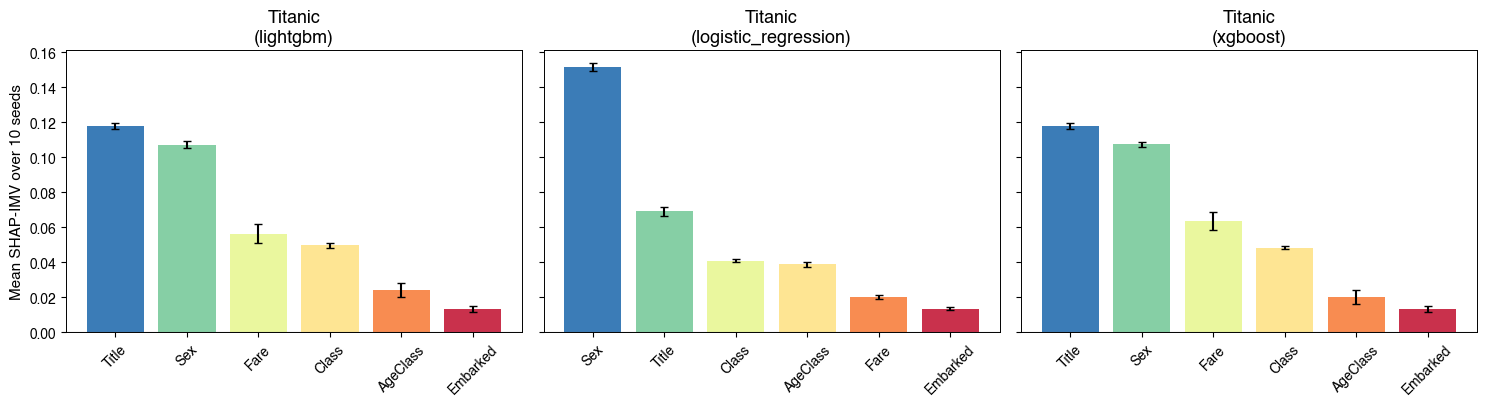

{'pdf': '../../../../CharlieRahal Dropbox/Charlie RAHAL/imv/imv_ml/new/IMV_ML/output/figures/shap_imv_titanic__shap_imv.pdf'}

In [2]:
models = list(summary["model"].unique())
fig, axes = plt.subplots(1, len(models), figsize=(5 * len(models), 4.2), sharey=True)
axes = np.atleast_1d(axes)
for ax, name in zip(axes, models):
    part = summary[summary.model == name].sort_values("mean", ascending=False)
    ax.bar(part["feature"], part["mean"], yerr=part["std"].fillna(0),
           capsize=3, color=spectral_colors(len(part)))
    ax.set_title(f"{TITLE}\n({name})")
    ax.tick_params(axis="x", rotation=45)
    ax.axhline(0, color="0.4", linewidth=0.8)
axes[0].set_ylabel(f"Mean SHAP-IMV over {len(SEEDS)} seeds")
fig.tight_layout()
paths = {file_format: relative_path(path, start=ARTIFACTS)
         for file_format, path in save_figure(
             fig, FIGURES / "shap_imv_titanic__shap_imv"
         ).items()}
plt.show()
paths


## 6. Top-five feature selection against SHAP, LIME and Anchors

Each attribution method ranks the features; the top five of each ranking are then
used to refit the same estimator, and accuracy and precision are averaged over
ten folds for each of the ten seeds.

SHAP-IMV reuses the Shapley values computed above. The three local baselines are
recomputed per seed and averaged, so every ranking is a ten-seed mean of one
global score per feature: mean |SHAP value|, mean |LIME weight|, and how often a
feature appears in the Anchors explanation.

Written to `output/examples/shap/<notebook>_top_5_features.csv`.


In [7]:
import logging

from sklearn.metrics import accuracy_score, precision_score
from sklearn.model_selection import StratifiedKFold

EXAMPLE = f"shap_imv_{DATASET}"
TABLES = Path(os.environ.get(
    "IMV_TABLE_DIR", PROJECT_ROOT / "output" / "examples" / "shap"
))
TABLES.mkdir(parents=True, exist_ok=True)
RANKINGS = RESULTS / "rankings" / RUN_SIGNATURE
RANKINGS.mkdir(parents=True, exist_ok=True)

TOP_K = 5
EVAL_SPLITS = 10          # every reported number is a mean over ten folds per seed
METHODS = ("shap_imv", "shap", "lime", "anchors")

# Explanation budget. SHAP is exact per row and costs almost nothing at this
# width; LIME and Anchors resample the model once per row, so they explain a
# seeded sample instead of every row.
SHAP_ROWS, SHAP_BACKGROUND = 2000, 200
LIME_ROWS, LIME_SAMPLES = 200, 2000
ANCHOR_ROWS, ANCHOR_THRESHOLD = 100, 0.95

# The standardised matrix the rankings and the refits both read.
X = frame[FEATURES].to_numpy(dtype=float)
y = frame["target"].to_numpy(dtype=int)

def sample_rows(matrix, n_rows, seed):
    """A reproducible row sample, or the whole matrix when it is already small."""
    if len(matrix) <= n_rows:
        return matrix
    generator = np.random.default_rng(seed)
    return matrix[generator.choice(len(matrix), size=n_rows, replace=False)]

def fit_full(model_name, seed):
    """The single model a ranking explains: same estimator, fitted on every row."""
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        return model_factories(seed)[model_name]().fit(X, y)

In [8]:
def shap_importance(model, model_name, seed):
    """Mean |SHAP value| per feature over the explained rows.

    XGBoost is read through its own `pred_contribs` interface rather than
    `shap.TreeExplainer`: both run the same exact TreeSHAP, but shap 0.49 — the
    last release supporting the numpy < 2 that alibi pins — cannot parse the
    list-valued `base_score` written by xgboost 3.
    """
    import shap

    rows = sample_rows(X, SHAP_ROWS, seed)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        if model_name == "logistic_regression":
            values = shap.LinearExplainer(
                model, sample_rows(X, SHAP_BACKGROUND, seed)).shap_values(rows)
        elif model_name == "xgboost":
            import xgboost

            values = model.get_booster().predict(
                xgboost.DMatrix(rows), pred_contribs=True)[:, :-1]  # drop the bias
        else:
            values = shap.TreeExplainer(model).shap_values(rows)
    values = np.asarray(values[1] if isinstance(values, list) else values)
    if values.ndim == 3:                     # (rows, features, classes)
        values = values[..., -1]
    return np.abs(values).mean(axis=0)

def lime_importance(model, seed):
    """Mean |local surrogate weight| per feature over the explained rows."""
    from lime.lime_tabular import LimeTabularExplainer

    # Binary columns are declared categorical: quartile bins over a two-valued
    # standardised column are degenerate and would hide the feature from LIME.
    categorical = [index for index in range(X.shape[1])
                   if len(np.unique(X[:, index])) <= 2]
    explainer = LimeTabularExplainer(
        X, feature_names=list(FEATURES), class_names=["0", "1"],
        categorical_features=categorical, discretize_continuous=True,
        mode="classification", random_state=seed,
    )
    rows = sample_rows(X, LIME_ROWS, seed)
    totals = np.zeros(X.shape[1])
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        for row in rows:
            explanation = explainer.explain_instance(
                row, model.predict_proba, num_features=X.shape[1],
                num_samples=LIME_SAMPLES, labels=(1,))
            for index, weight in explanation.as_map()[1]:
                totals[index] += abs(weight)
    return totals / len(rows)

def anchor_importance(model, seed):
    """How often a feature anchors a prediction, tie-broken by its position.

    Anchors are grown greedily, so a feature added early is the stronger reason.
    The position term is scaled below one, which keeps it a tie-break: it can
    never outrank a difference in how often a feature appears at all.
    """
    from alibi.explainers import AnchorTabular

    # Rows whose anchor misses the threshold are logged one line each, which
    # across a hundred rows and thirty jobs would bury everything else.
    logging.getLogger("alibi").setLevel(logging.ERROR)
    counts, positions = np.zeros(X.shape[1]), np.zeros(X.shape[1])
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        explainer = AnchorTabular(lambda rows: model.predict(np.asarray(rows)),
                                  feature_names=list(FEATURES), seed=seed)
        explainer.fit(X, disc_perc=(25, 50, 75))
        rows = sample_rows(X, ANCHOR_ROWS, seed)
        for row in rows:
            try:
                anchor = explainer.explain(
                    row, threshold=ANCHOR_THRESHOLD).data["raw"]["feature"]
            except Exception as error:       # a row the beam search cannot anchor
                print(f"anchors: skipping a row ({type(error).__name__}: {error})")
                continue
            for position, index in enumerate(anchor):
                counts[index] += 1
                positions[index] += 1 / (position + 1)
    return counts / len(rows) + 0.5 * positions / (len(rows) * max(counts.max(), 1))

In [9]:
def ranking_path(model_name, method, seed):
    return RANKINGS / f"{method}_{model_name}_seed_{seed}.json"

def read_ranking(model_name, method, seed):
    cached = json.loads(ranking_path(model_name, method, seed).read_text())
    importance = cached.get("importance", [])
    if cached.get("features") != list(FEATURES) or len(importance) != len(FEATURES):
        raise ValueError(f"invalid ranking: {ranking_path(model_name, method, seed).name}")
    importance = np.asarray(importance, dtype=float)
    if not np.isfinite(importance).all():
        raise ValueError(f"invalid ranking: {ranking_path(model_name, method, seed).name}")
    return importance

def compute_ranking(model_name, method, seed):
    """One global importance vector, checkpointed like the SHAP-IMV jobs above."""
    model = fit_full(model_name, seed)
    importance = {
        "shap": lambda: shap_importance(model, model_name, seed),
        "lime": lambda: lime_importance(model, seed),
        "anchors": lambda: anchor_importance(model, seed),
    }[method]()
    path = ranking_path(model_name, method, seed)
    temporary = path.with_name(f".{path.name}.{os.getpid()}.tmp")
    try:
        temporary.write_text(json.dumps({
            "features": list(FEATURES),
            "importance": [float(value) for value in importance],
        }))
        os.replace(temporary, path)
    finally:
        temporary.unlink(missing_ok=True)
    return model_name, method, seed, importance

# SHAP-IMV needs no further work here; the other three are one job per seed.
ranking_jobs = [(model_name, method, seed)
                for model_name in MODEL_NAMES
                for method in METHODS if method != "shap_imv"
                for seed in SEEDS]
rankings, pending_rankings = {}, []
for job in ranking_jobs:
    if FORCE_RECOMPUTE:
        pending_rankings.append(job)
        continue
    try:
        rankings[job] = read_ranking(*job)
    except (FileNotFoundError, OSError, ValueError) as error:
        pending_rankings.append(job)
        if not isinstance(error, FileNotFoundError):
            print(f"recomputing {job[1]} {job[0]} seed {job[2]}: {error}")

print(f"{mode} mode; run {RUN_SIGNATURE}: "
      f"{len(rankings)}/{len(ranking_jobs)} rankings restored; "
      f"running {len(pending_rankings)} with {OUTER_N_JOBS} workers")
if pending_rankings:
    with parallel_config(backend="loky", inner_max_num_threads=1):
        stream = Parallel(
            n_jobs=OUTER_N_JOBS, return_as="generator_unordered",
            batch_size=1, pre_dispatch=OUTER_N_JOBS,
        )(delayed(compute_ranking)(*job) for job in pending_rankings)
        with tqdm(total=len(ranking_jobs), initial=len(rankings),
                  desc="baseline rankings", unit="job") as progress:
            for model_name, method, seed, importance in stream:
                rankings[(model_name, method, seed)] = importance
                progress.set_postfix_str(f"{method} {model_name} seed {seed}")
                progress.update()

if len(rankings) != len(ranking_jobs):
    raise RuntimeError(f"expected {len(ranking_jobs)} rankings, found {len(rankings)}")

# One importance vector per (estimator, method): the ten-seed mean in both cases.
shap_imv_means = summary.set_index(["model", "feature"])["mean"]
importance_by_cell = {
    (model_name, method): (
        shap_imv_means.loc[model_name].reindex(FEATURES).to_numpy(dtype=float)
        if method == "shap_imv" else
        np.mean([rankings[(model_name, method, seed)] for seed in SEEDS], axis=0)
    )
    for model_name in MODEL_NAMES for method in METHODS
}

resume mode; run c04c4908e963: 0/90 rankings restored; running 90 with 11 workers


baseline rankings:   0%|          | 0/90 [00:00<?, ?job/s]

../../../../miniforge3/envs/imv/lib/python3.11/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.


In [10]:
def top_k(importance, k=TOP_K):
    """The k strongest features, best first; ties fall back to the FEATURES order."""
    order = sorted(range(len(FEATURES)),
                   key=lambda index: (-importance[index], index))
    return ([FEATURES[index] for index in order[:k]],
            [FEATURES[index] for index in order[k:]])

def evaluate(model_name, selected):
    """Accuracy and precision per fold: EVAL_SPLITS folds for each of the seeds."""
    subset = frame[list(selected)].to_numpy(dtype=float)
    accuracy, precision = [], []
    for seed in SEEDS:
        folds = StratifiedKFold(n_splits=EVAL_SPLITS, shuffle=True, random_state=seed)
        seed_accuracy, seed_precision = [], []
        for train, test in folds.split(subset, y):
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                model = model_factories(seed)[model_name]().fit(subset[train], y[train])
                predicted = model.predict(subset[test])
            seed_accuracy.append(accuracy_score(y[test], predicted))
            seed_precision.append(precision_score(y[test], predicted, zero_division=0))
        accuracy.append(seed_accuracy)
        precision.append(seed_precision)
    return np.asarray(accuracy), np.asarray(precision)

rows, evaluated = [], {}
for model_name in MODEL_NAMES:
    for method in METHODS:
        importance = importance_by_cell[(model_name, method)]
        selected, dropped = top_k(importance)
        # Dropping one of six features leaves at most six distinct subsets, and
        # the methods often agree, so each subset is cross-validated once.
        key = (model_name, tuple(sorted(selected)))
        if key not in evaluated:
            evaluated[key] = evaluate(model_name, selected)
        accuracy, precision = evaluated[key]
        rows.append({
            "example": EXAMPLE,
            "dataset": TITLE,
            "model": model_name,
            "method": method,
            "k": TOP_K,
            "selected_features": ";".join(selected),
            "dropped_features": ";".join(dropped),
            "importance": ";".join(f"{importance[FEATURES.index(name)]:.6g}"
                                   for name in selected),
            "accuracy_mean": accuracy.mean(),
            "accuracy_std_across_seeds": accuracy.mean(axis=1).std(ddof=1),
            "precision_mean": precision.mean(),
            "precision_std_across_seeds": precision.mean(axis=1).std(ddof=1),
            "n_seeds": len(SEEDS),
            "n_splits": EVAL_SPLITS,
        })

top_features = pd.DataFrame(rows)
write_csv_atomic(top_features, TABLES / f"{EXAMPLE}_top_{TOP_K}_features.csv")
print(relative_path(TABLES / f"{EXAMPLE}_top_{TOP_K}_features.csv"))
(top_features[["model", "method", "selected_features", "dropped_features",
               "accuracy_mean", "precision_mean"]]
 .assign(accuracy_mean=lambda table: (100 * table.accuracy_mean).round(2),
         precision_mean=lambda table: (100 * table.precision_mean).round(2)))

../../output/examples/shap/shap_imv_titanic_top_5_features.csv


,model,method,selected_features,dropped_features,accuracy_mean,precision_mean
0,logistic_regression,shap_imv,Sex;Title;Class;AgeClass;Fare,Embarked,79.50,74.36
1,logistic_regression,shap,Sex;Class;AgeClass;Title;Embarked,Fare,79.66,74.96
2,logistic_regression,lime,Sex;Class;Embarked;AgeClass;Title,Fare,79.66,74.96
3,logistic_regression,anchors,Sex;AgeClass;Title;Class;Fare,Embarked,79.50,74.36
4,xgboost,shap_imv,Title;Sex;Fare;Class;AgeClass,Embarked,80.89,78.75
5,xgboost,shap,Title;Class;Sex;AgeClass;Fare,Embarked,80.89,78.75
6,xgboost,lime,Title;Class;Sex;Embarked;AgeClass,Fare,80.44,80.47
7,xgboost,anchors,Title;Sex;Class;Fare;AgeClass,Embarked,80.89,78.75
8,lightgbm,shap_imv,Title;Sex;Fare;Class;AgeClass,Embarked,81.00,79.48
9,lightgbm,shap,Title;Sex;Class;AgeClass;Fare,Embarked,81.00,79.48
